In [1]:
!pip install torch torchvision
!pip install albumentations

   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.7 MB ? eta -:--:--
   ------------ --------------------------- 0.5/1.7 MB 1.7 MB/s eta 0:00:01
   ------------------------ --------------- 1.0/1.7 MB 1.9 MB/s eta 0:00:01
   ------------------------------ --------- 1.3/1.7 MB 2.0 MB/s eta 0:00:01
   ---------------------------------------- 1.7/1.7 MB 2.0 MB/s eta 0:00:00
  Using cached numpy-2.2.6-cp312-cp312-win_amd64.whl.metadata (60 kB)
   ---------------------------------------- 0.0/38.9 MB ? eta -:--:--
    --------------------------------------- 0.8/38.9 MB 4.2 MB/s eta 0:00:10
   - -------------------------------------- 1.6/38.9 MB 4.2 MB/s eta 0:00:09
   -- ------------------------------------- 2.6/38.9 MB 4.4 MB/s eta 0:00:09
   --- ------------------------------------ 3.7/38.9 MB 4.6 MB/s eta 0:00:08
   ----- ---------------------------------- 5.0/38.9 MB 4.8 MB/s eta 0:00:08
   ----- ------------------------

  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mediapipe 0.10.21 requires numpy<2, but you have numpy 2.2.6 which is incompatible.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.2.6 which is incompatible.


In [7]:
!pip install dataset

   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   -------------------------- ------------- 1.0/1.6 MB 12.5 MB/s eta 0:00:01
   -------------------------- ------------- 1.0/1.6 MB 12.5 MB/s eta 0:00:01
   -------------------------- ------------- 1.0/1.6 MB 12.5 MB/s eta 0:00:01
   -------------------------- ------------- 1.0/1.6 MB 12.5 MB/s eta 0:00:01
   ---------------------------------------- 1.6/1.6 MB 1.5 MB/s eta 0:00:00

   ------ --------------------------------- 1/6 [Mako]
   ------------- -------------------------- 2/6 [greenlet]
   -------------------- ------------------- 3/6 [sqlalchemy]
   -------------------- ------------------- 3/6 [sqlalchemy]
   -------------------- ------------------- 3/6 [sqlalchemy]
   -------------------- ------------------- 3/6 [sqlalchemy]
   -------------------- ------------------- 3/6 [sqlalchemy]
   -------------------- ------------------- 3/6 [sqlalchemy]
   -------------------- ------------------- 3/6 [sqlalchemy]
   --

### loading your data, preprocessing it, and applying augmentations on-the-fly.

In [34]:
# dataset.py(class)

import os
import glob
import torch
import rasterio
import numpy as np
from torch.utils.data import Dataset

class GlacialLakeDataset(Dataset):
    """
    Custom PyTorch Dataset for glacial lake segmentation.
    Reads image and mask chunks, applies normalization, augmentation,
    and converts them to PyTorch tensors.
    """
    def __init__(self, image_dir, mask_dir, augmentations=None):
        """
        Args:
            image_dir (str): Directory with all the input image chunks.
            mask_dir (str): Directory with all the corresponding mask chunks.
            augmentations (albumentations.Compose): Transformations to apply.
        """
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.augmentations = augmentations

        # Get a sorted list of image file paths to ensure alignment
        self.image_files = sorted(glob.glob(os.path.join(image_dir, "*.tif")))

    def __len__(self):
        """Returns the total number of samples in the dataset."""
        return len(self.image_files)

    def __getitem__(self, idx):
        """
        Fetches the image and mask at a given index, preprocesses them,
        and returns them as tensors.
        """
        # 1. Get image and mask file paths
        img_path = self.image_files[idx]
        img_filename = os.path.basename(img_path)
        mask_filename = img_filename.replace('input_stack_chunk_', 'lake_mask_chunk_')
        mask_path = os.path.join(self.mask_dir, mask_filename)

        # 2. Open files with rasterio and create NumPy arrays
        with rasterio.open(img_path) as src:
            # Get data type to determine max value for normalization
            dtype = src.profile['dtype']
            if np.issubdtype(dtype, np.integer):
                max_val = np.iinfo(dtype).max
            else: # Fallback for float types
                max_val = 1.0

            # Read and normalize the image to a [0, 1] range
            image = src.read() / max_val

        with rasterio.open(mask_path) as src:
            # Read mask and ensure it's a single channel
            mask = src.read(1)
            # Normalize mask to 0 or 1, and ensure correct data type
            mask = (mask > 0).astype(np.float32)

        # 3. Apply augmentations (if any)
        if self.augmentations:
            augmented = self.augmentations(image=image.transpose(1, 2, 0), mask=mask)
            image = augmented['image'].transpose(2, 1, 0)
            mask = augmented['mask']

        # 4. Convert to PyTorch Tensors
        # Add a channel dimension to the mask (H, W) -> (1, H, W)
        if mask.ndim == 2:
            mask = np.expand_dims(mask, axis=0)
            
        return {
            "image": torch.from_numpy(image).float(),
            "mask": torch.from_numpy(mask).float()
        }

### Calling Data augmentation class while trianing , below is a sample

In [35]:
import os
import albumentations as A
from albumentations.pytorch import ToTensorV2
#from dataset import GlacialLakeDataset # This line should be commented out or removed in Jupyter

if __name__ == '__main__':
    # --- 1. Define Correct Paths to Your Data ---
    # These paths point directly to the folders you created in the previous step
    TRAIN_IMG_DIR = r"D:\Coding\Hackathon\Glacial_Lake_Detection_BAH-2025\data\LISS3\segments\input_stack\LISS3_1\training"
    TRAIN_MSK_DIR = r"D:\Coding\Hackathon\Glacial_Lake_Detection_BAH-2025\data\LISS3\segments\layer_mask\LISS3_1\training"

    VAL_IMG_DIR = r"D:\Coding\Hackathon\Glacial_Lake_Detection_BAH-2025\data\LISS3\segments\input_stack\LISS3_1\validation"
    VAL_MSK_DIR = r"D:\Coding\Hackathon\Glacial_Lake_Detection_BAH-2025\data\LISS3\segments\layer_mask\LISS3_1\validation"

    # --- 2. Define Augmentations ---
    # Define transformations for the training set
    train_transforms = A.Compose([
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.5),
    ])

    # Validation set should not have random augmentations
    val_transforms = None

    # --- 3. Instantiate the Datasets ---
    train_dataset = GlacialLakeDataset(
        image_dir=TRAIN_IMG_DIR,
        mask_dir=TRAIN_MSK_DIR,
        augmentations=train_transforms
    )

    val_dataset = GlacialLakeDataset(
        image_dir=VAL_IMG_DIR,
        mask_dir=VAL_MSK_DIR,
        augmentations=val_transforms
    )

    # --- 4. Verify the output of one sample ---
    print(f"Number of training samples: {len(train_dataset)}")
    print(f"Number of validation samples: {len(val_dataset)}")

    # Check if the dataset is not empty before trying to access an element
    if len(train_dataset) > 0:
        # Get the first sample from the training set
        sample = train_dataset[0]
        image_tensor = sample['image']
        mask_tensor = sample['mask']

        print("\nVerifying one sample from the dataset:")
        print(f"  Image tensor shape: {image_tensor.shape}")
        print(f"  Image tensor data type: {image_tensor.dtype}")
        print(f"  Mask tensor shape: {mask_tensor.shape}")
        print(f"  Mask tensor data type: {mask_tensor.dtype}")
    else:
        print("\nCould not verify sample because training dataset is empty.")

Number of training samples: 136
Number of validation samples: 18

Verifying one sample from the dataset:
  Image tensor shape: torch.Size([8, 256, 256])
  Image tensor data type: torch.float32
  Mask tensor shape: torch.Size([1, 256, 256])
  Mask tensor data type: torch.float32


### Data Loader

This script will import your custom dataset, create instances for your training, validation, and test sets, and then wrap them in DataLoader

In [36]:
import os
import torch
import albumentations as A
from torch.utils.data import DataLoader

# This line should be commented out or removed in Jupyter if the class is in a cell above
# from dataset import GlacialLakeDataset 

# --- Main execution block ---
if __name__ == '__main__':
    # --- 1. Corrected Configuration and Hyperparameters ---
    # These paths point directly to where your split data is located.
    TRAIN_IMG_DIR = r"D:\Coding\Hackathon\Glacial_Lake_Detection_BAH-2025\data\LISS3\segments\input_stack\LISS3_1\training"
    TRAIN_MSK_DIR = r"D:\Coding\Hackathon\Glacial_Lake_Detection_BAH-2025\data\LISS3\segments\layer_mask\LISS3_1\training"

    VAL_IMG_DIR = r"D:\Coding\Hackathon\Glacial_Lake_Detection_BAH-2025\data\LISS3\segments\input_stack\LISS3_1\validation"
    VAL_MSK_DIR = r"D:\Coding\Hackathon\Glacial_Lake_Detection_BAH-2025\data\LISS3\segments\layer_mask\LISS3_1\validation"
    
    # Hyperparameters
    BATCH_SIZE = 4 
    NUM_WORKERS = 0 # Start with 0 in Jupyter notebooks to avoid issues

    # --- 2. Define Augmentations ---
    train_transforms = A.Compose([
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.5),
    ])
    val_transforms = None # No augmentations for validation

    # --- 3. Instantiate Datasets ---
    print("Instantiating datasets...")
    train_dataset = GlacialLakeDataset(
        image_dir=TRAIN_IMG_DIR,
        mask_dir=TRAIN_MSK_DIR,
        augmentations=train_transforms
    )
    val_dataset = GlacialLakeDataset(
        image_dir=VAL_IMG_DIR,
        mask_dir=VAL_MSK_DIR,
        augmentations=val_transforms
    )
    print(f"  - Training samples: {len(train_dataset)}")
    print(f"  - Validation samples: {len(val_dataset)}")


    # --- 4. Create DataLoaders ---
    # Add a check to ensure datasets are not empty before creating loaders
    if len(train_dataset) > 0:
        print("\nCreating DataLoaders...")
        train_loader = DataLoader(
            dataset=train_dataset,
            batch_size=BATCH_SIZE,
            shuffle=True,
            num_workers=NUM_WORKERS,
            pin_memory=True
        )

        val_loader = DataLoader(
            dataset=val_dataset,
            batch_size=BATCH_SIZE,
            shuffle=False,
            num_workers=NUM_WORKERS,
            pin_memory=True
        )
        print("DataLoaders created successfully.")

        # --- 5. Verify a Batch from the DataLoader ---
        print("\nVerifying one batch from the training loader...")
        data_batch = next(iter(train_loader))
        images = data_batch['image']
        masks = data_batch['mask']

        print(f"  - Batch of images shape: {images.shape}")
        print(f"  - Batch of masks shape:  {masks.shape}")
        print(f"  - Image data type: {images.dtype}")
        print(f"  - Mask data type:  {masks.dtype}")
    else:
        print("\nSkipping DataLoader creation because datasets are empty. Please check your paths.")

Instantiating datasets...
  - Training samples: 136
  - Validation samples: 18

Creating DataLoaders...
DataLoaders created successfully.

Verifying one batch from the training loader...
  - Batch of images shape: torch.Size([4, 8, 256, 256])
  - Batch of masks shape:  torch.Size([4, 1, 256, 256])
  - Image data type: torch.float32
  - Mask data type:  torch.float32


### defining and training a attention U-Net model.

A standard U-Net model architecture in PyTorch.

A full training loop to train the model on your data.

Logic to handle training on a GPU if available.

In [37]:
import torch

print(f"PyTorch Version: {torch.__version__}")
print(f"Is CUDA available? ==> {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"CUDA version: {torch.version.cuda}")
    print(f"Device Name: {torch.cuda.get_device_name(0)}")


PyTorch Version: 2.5.1+cu121
Is CUDA available? ==> True
CUDA version: 12.1
Device Name: NVIDIA GeForce RTX 3050 Laptop GPU


In [38]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm import tqdm
import albumentations as A
import rasterio
import numpy as np
import glob

# ==============================================================================
# 1. DATASET CLASS
# ==============================================================================
class GlacialLakeDataset(Dataset):
    """
    Custom PyTorch Dataset for glacial lake segmentation.
    Reads image and mask chunks, applies normalization, augmentation,
    and converts them to PyTorch tensors.
    """
    def __init__(self, image_dir, mask_dir, augmentations=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.augmentations = augmentations
        self.image_files = sorted(glob.glob(os.path.join(image_dir, "*.tif")))

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = self.image_files[idx]
        img_filename = os.path.basename(img_path)
        mask_filename = img_filename.replace('input_stack_chunk_', 'lake_mask_chunk_')
        mask_path = os.path.join(self.mask_dir, mask_filename)

        with rasterio.open(img_path) as src:
            dtype = src.profile['dtype']
            if np.issubdtype(dtype, np.integer):
                max_val = np.iinfo(dtype).max
            else:
                max_val = 1.0
            image = src.read().astype(np.float32) / max_val

        with rasterio.open(mask_path) as src:
            mask = src.read(1)
            mask = (mask > 0).astype(np.float32)

        if self.augmentations:
            augmented = self.augmentations(image=image.transpose(1, 2, 0), mask=mask)
            image = augmented['image'].transpose(2, 0, 1) # Correct transpose back to (C, H, W)
            mask = augmented['mask']

        if mask.ndim == 2:
            mask = np.expand_dims(mask, axis=0)
            
        return {
            "image": torch.from_numpy(image).float(),
            "mask": torch.from_numpy(mask).float()
        }

# ==============================================================================
# 2. U-NET MODEL ARCHITECTURE
# ==============================================================================
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.double_conv(x)

class UNET(nn.Module):
    def __init__(self, in_channels=8, out_channels=1, features=[64, 128, 256, 512]):
        super(UNET, self).__init__()
        self.ups = nn.ModuleList()
        self.downs = nn.ModuleList()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        for feature in features:
            self.downs.append(DoubleConv(in_channels, feature))
            in_channels = feature

        for feature in reversed(features):
            self.ups.append(nn.ConvTranspose2d(feature * 2, feature, kernel_size=2, stride=2))
            self.ups.append(DoubleConv(feature * 2, feature))

        self.bottleneck = DoubleConv(features[-1], features[-1] * 2)
        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        skip_connections = []
        for down in self.downs:
            x = down(x)
            skip_connections.append(x)
            x = self.pool(x)
        x = self.bottleneck(x)
        skip_connections = skip_connections[::-1]
        for idx in range(0, len(self.ups), 2):
            x = self.ups[idx](x)
            skip_connection = skip_connections[idx // 2]
            if x.shape != skip_connection.shape:
                x = nn.functional.interpolate(x, size=skip_connection.shape[2:])
            concat_skip = torch.cat((skip_connection, x), dim=1)
            x = self.ups[idx + 1](concat_skip)
        return self.final_conv(x)

# ==============================================================================
# 3. IMPROVED LOSS FUNCTION
# ==============================================================================
class DiceLoss(nn.Module):
    def __init__(self):
        super(DiceLoss, self).__init__()
    def forward(self, inputs, targets, smooth=1):
        inputs = torch.sigmoid(inputs)       
        inputs = inputs.view(-1)
        targets = targets.view(-1)
        intersection = (inputs * targets).sum()                            
        dice = (2.*intersection + smooth)/(inputs.sum() + targets.sum() + smooth)  
        return 1 - dice

class DiceBCELoss(nn.Module):
    def __init__(self):
        super(DiceBCELoss, self).__init__()
        self.dice_loss = DiceLoss()
        self.bce_loss = nn.BCEWithLogitsLoss()
    def forward(self, inputs, targets, smooth=1):
        total_loss = self.bce_loss(inputs, targets) + self.dice_loss(inputs, targets)
        return total_loss

# ==============================================================================
# 4. TRAINING AND VALIDATION FUNCTIONS
# ==============================================================================
def train_one_epoch(loader, model, optimizer, loss_fn, device):
    loop = tqdm(loader, desc="Training")
    running_loss = 0.0
    model.train()
    for batch in loop:
        images = batch["image"].to(device)
        masks = batch["mask"].to(device)
        predictions = model(images)
        loss = loss_fn(predictions, masks)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        loop.set_postfix(loss=loss.item())
    return running_loss / len(loader)

def evaluate_model(loader, model, loss_fn, device):
    model.eval()
    running_loss = 0.0
    with torch.no_grad():
        for batch in tqdm(loader, desc="Validation"):
            images = batch["image"].to(device)
            masks = batch["mask"].to(device)
            predictions = model(images)
            loss = loss_fn(predictions, masks)
            running_loss += loss.item()
    return running_loss / len(loader)

class AttentionBlock(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super(AttentionBlock, self).__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )
        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )
        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        psi = self.relu(g1 + x1)
        psi = self.psi(psi)
        return x * psi

class AttentionUNET(nn.Module):
    def __init__(self, in_channels=8, out_channels=1, features=[64, 128, 256, 512]):
        super(AttentionUNET, self).__init__()
        self.downs = nn.ModuleList()
        self.ups = nn.ModuleList()
        self.attentions = nn.ModuleList()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Encoder
        for feature in features:
            self.downs.append(DoubleConv(in_channels, feature))
            in_channels = feature

        # Bottleneck
        self.bottleneck = DoubleConv(features[-1], features[-1] * 2)

        # Decoder with Attention Gates
        for feature in reversed(features):
            # THE ONLY CHANGE IS IN THE LINE BELOW: F_g is now 'feature' instead of 'feature * 2'
            self.attentions.append(AttentionBlock(F_g=feature, F_l=feature, F_int=feature // 2))
            self.ups.append(nn.ConvTranspose2d(feature * 2, feature, kernel_size=2, stride=2))
            self.ups.append(DoubleConv(feature * 2, feature))

        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        skip_connections = []
        # Encode
        for down in self.downs:
            x = down(x)
            skip_connections.append(x)
            x = self.pool(x)
        
        x = self.bottleneck(x)
        skip_connections = skip_connections[::-1]

        # Decode with attention
        for i in range(len(self.ups) // 2):
            x = self.ups[i*2](x) # Upsampling
            skip_connection = skip_connections[i]
            
            # Apply attention gate
            attention_map = self.attentions[i](g=x, x=skip_connection)
            
            concat_skip = torch.cat((attention_map, x), dim=1)
            x = self.ups[i*2 + 1](concat_skip) # DoubleConv

        return self.final_conv(x)

# ==============================================================================
# 5. MAIN EXECUTION BLOCK
# ==============================================================================
if __name__ == '__main__':
    # --- Configuration ---
    LEARNING_RATE = 1e-4
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    BATCH_SIZE = 4
    NUM_WORKERS = 0
    NUM_EPOCHS = 25
    
    TRAIN_IMG_DIR = r"D:\Coding\Hackathon\Glacial_Lake_Detection_BAH-2025\data\LISS3\segments\input_stack\LISS3_1\training"
    TRAIN_MSK_DIR = r"D:\Coding\Hackathon\Glacial_Lake_Detection_BAH-2025\data\LISS3\segments\layer_mask\LISS3_1\training"
    VAL_IMG_DIR = r"D:\Coding\Hackathon\Glacial_Lake_Detection_BAH-2025\data\LISS3\segments\input_stack\LISS3_1\validation"
    VAL_MSK_DIR = r"D:\Coding\Hackathon\Glacial_Lake_Detection_BAH-2025\data\LISS3\segments\layer_mask\LISS3_1\validation"

    # --- Data Augmentation ---
    train_transforms = A.Compose([
        A.HorizontalFlip(p=0.5), A.VerticalFlip(p=0.5), A.RandomRotate90(p=0.5),
    ])

    # --- Datasets and DataLoaders ---
    train_dataset = GlacialLakeDataset(TRAIN_IMG_DIR, TRAIN_MSK_DIR, train_transforms)
    val_dataset = GlacialLakeDataset(VAL_IMG_DIR, VAL_MSK_DIR, None)
    train_loader = DataLoader(train_dataset, BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
    val_loader = DataLoader(val_dataset, BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

    # --- Model, Loss, and Optimizer ---
    model = AttentionUNET(in_channels=8, out_channels=1).to(DEVICE) 

    loss_fn = DiceBCELoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    # --- Training Loop ---
    print(f"Starting training on {DEVICE}...")
    best_val_loss = float("inf")
    for epoch in range(NUM_EPOCHS):
        print(f"\n--- Epoch {epoch+1}/{NUM_EPOCHS} ---")
        train_loss = train_one_epoch(train_loader, model, optimizer, loss_fn, DEVICE)
        val_loss = evaluate_model(val_loader, model, loss_fn, DEVICE)
        print(f"Epoch {epoch+1} Summary: Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), "best_model.pth")
            print("=> Saved new best model")

    print("\nTraining complete!")

Starting training on cuda...

--- Epoch 1/25 ---


Validation: 100%|████████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00,  7.08it/s]


Epoch 1 Summary: Train Loss: 1.4940 | Val Loss: 1.4576
=> Saved new best model

--- Epoch 2/25 ---


Validation: 100%|████████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00,  6.97it/s]


Epoch 2 Summary: Train Loss: 1.3359 | Val Loss: 1.3096
=> Saved new best model

--- Epoch 3/25 ---


...

Epoch 23 Summary: Train Loss: 1.0834 | Val Loss: 1.0727
=> Saved new best model

--- Epoch 24/25 ---


Validation: 100%|████████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00,  7.05it/s]


Epoch 24 Summary: Train Loss: 1.0808 | Val Loss: 1.0961

--- Epoch 25/25 ---


Validation: 100%|████████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00,  6.92it/s]

Epoch 25 Summary: Train Loss: 1.0754 | Val Loss: 1.0737

Training complete!


### Evaluate Model Performance on the Test Set

In [51]:
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from tqdm import tqdm

# Ensure your UNET and GlacialLakeDataset classes are defined in previous cells

def check_accuracy(loader, model, device="cuda"):
    """Calculates segmentation metrics (Accuracy, Dice, IoU) on a dataset."""
    num_correct = 0
    num_pixels = 0
    dice_score = 0
    jaccard_index = 0 # Also known as Intersection over Union (IoU)
    model.eval()

    with torch.no_grad():
        for batch in tqdm(loader, desc="Testing"):
            x = batch["image"].to(device)
            y = batch["mask"].to(device)

            # Get model predictions
            preds = torch.sigmoid(model(x))
            preds = (preds > 0.5).float() # Binarize the predictions

            # Calculate pixel accuracy
            num_correct += (preds == y).sum()
            num_pixels += torch.numel(preds)

            # Calculate Dice and Jaccard scores
            intersection = (preds * y).sum()
            union = (preds + y).sum() - intersection
            
            dice_score += (2. * intersection) / ((preds + y).sum() + 1e-8)
            jaccard_index += intersection / (union + 1e-8)

    # Calculate final metrics
    final_accuracy = (num_correct / num_pixels) * 100
    final_dice = dice_score / len(loader)
    final_jaccard = jaccard_index / len(loader)

    print(f"\n--- Test Set Performance ---")
    print(f"Pixel Accuracy: {final_accuracy:.2f}%")
    print(f"Dice Score: {final_dice:.4f}")
    print(f"Jaccard/IoU: {final_jaccard:.4f}")

    model.train()
    return final_accuracy, final_dice, final_jaccard


if __name__ == '__main__':
    # --- Configuration ---
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    BATCH_SIZE = 4
    NUM_WORKERS = 0

    # Define paths to your TEST data
    TEST_IMG_DIR = r"D:\Coding\Hackathon\Glacial_Lake_Detection_BAH-2025\data\LISS3\segments\input_stack\LISS3_1\testing"
    TEST_MSK_DIR = r"D:\Coding\Hackathon\Glacial_Lake_Detection_BAH-2025\data\LISS3\segments\layer_mask\LISS3_1\testing"
    MODEL_PATH = "best_model_attention.pth"

    # --- Load Model and Data ---
    print("Loading test data and best model...")
    
    # THE ONLY CHANGE IS HERE: Use AttentionUNET instead of UNET
    model = AttentionUNET(in_channels=8, out_channels=1).to(DEVICE)
    
    # Load the saved weights
    # Added weights_only=True to address the warning in your output
    model.load_state_dict(torch.load(MODEL_PATH, weights_only=True))

    # Create the test dataset and dataloader
    test_dataset = GlacialLakeDataset(TEST_IMG_DIR, TEST_MSK_DIR, None)
    test_loader = DataLoader(test_dataset, BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

    # --- Evaluate the Model ---
    check_accuracy(test_loader, model, device=DEVICE)

Loading test data and best model...


Testing: 100%|███████████████████████████████████████████████████████████████████████████| 5/5 [00:04<00:00,  1.10it/s]



--- Test Set Performance ---
Pixel Accuracy: 99.77%
Dice Score: 0.1493
Jaccard/IoU: 0.1191


Generating visualizations for all 18 test samples...


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.7894737..0.9327731].



Displaying Sample 1/18


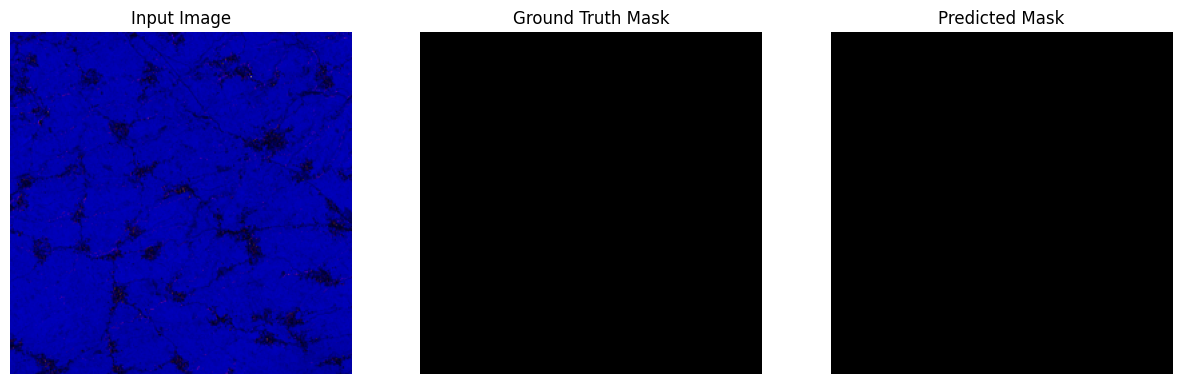

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.42696628..0.71267605].



Displaying Sample 2/18


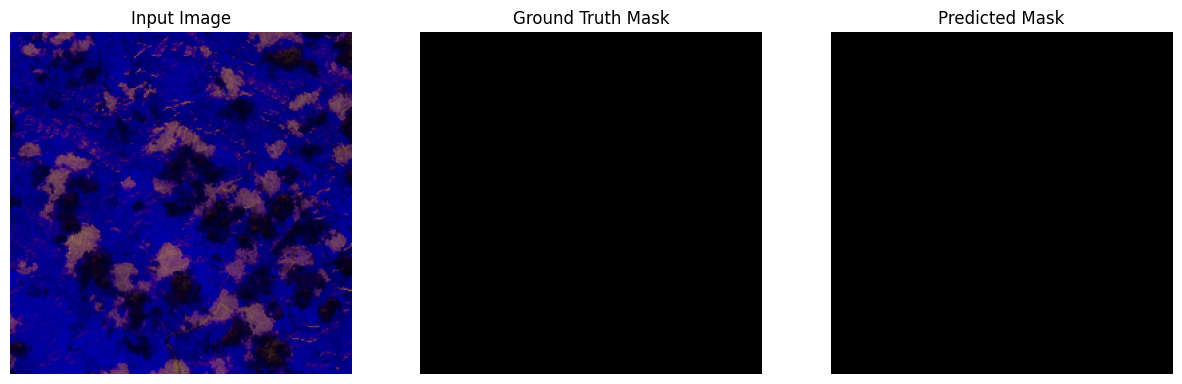

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5706806..1.0].



Displaying Sample 3/18


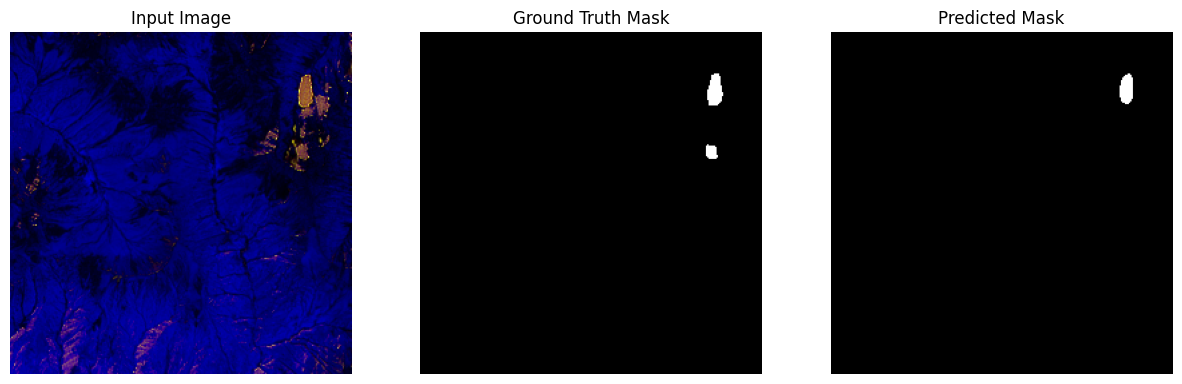

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5897436..1.0].



Displaying Sample 4/18


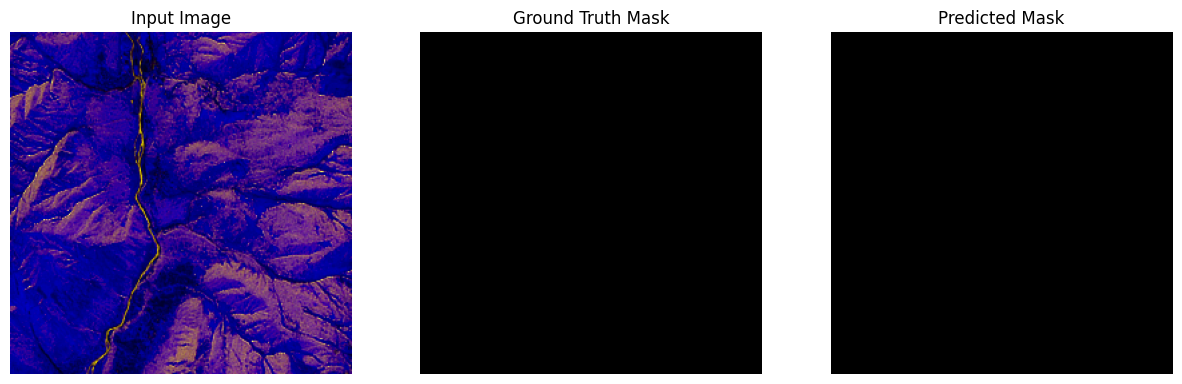

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.59241706..1.0].



Displaying Sample 5/18


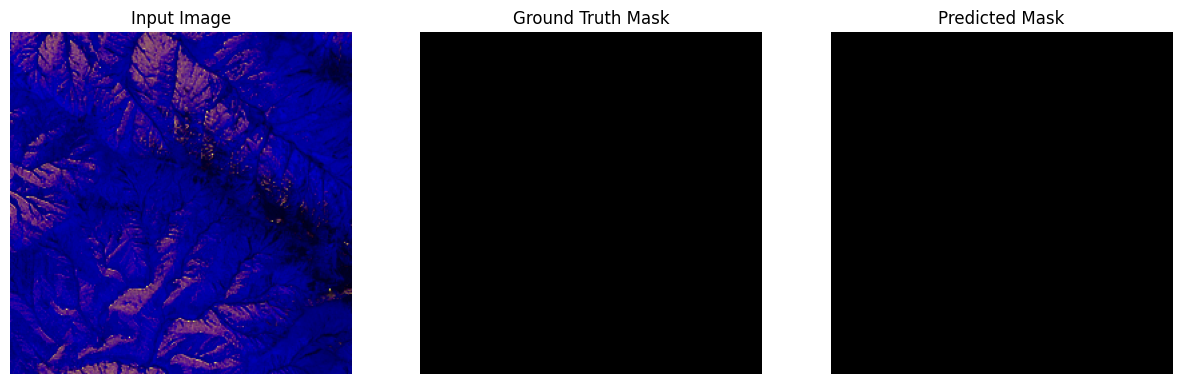

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.66292137..1.0].



Displaying Sample 6/18


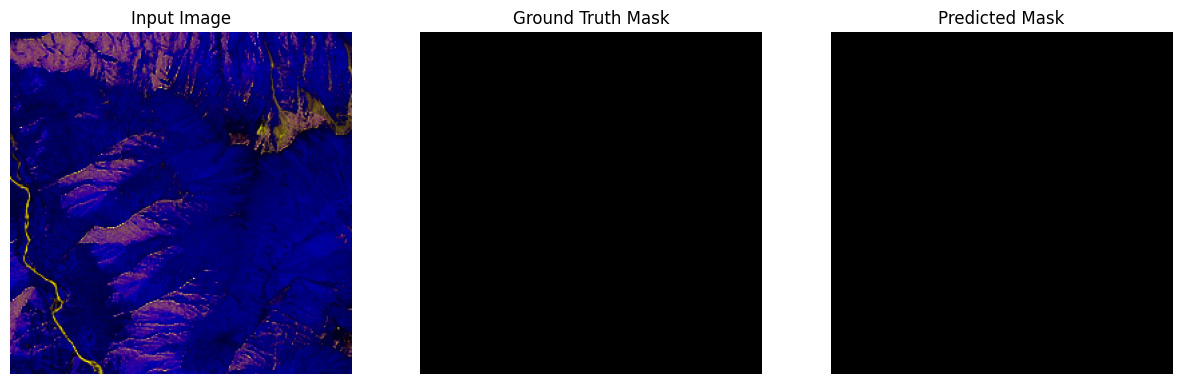

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.62416106..1.0].



Displaying Sample 7/18


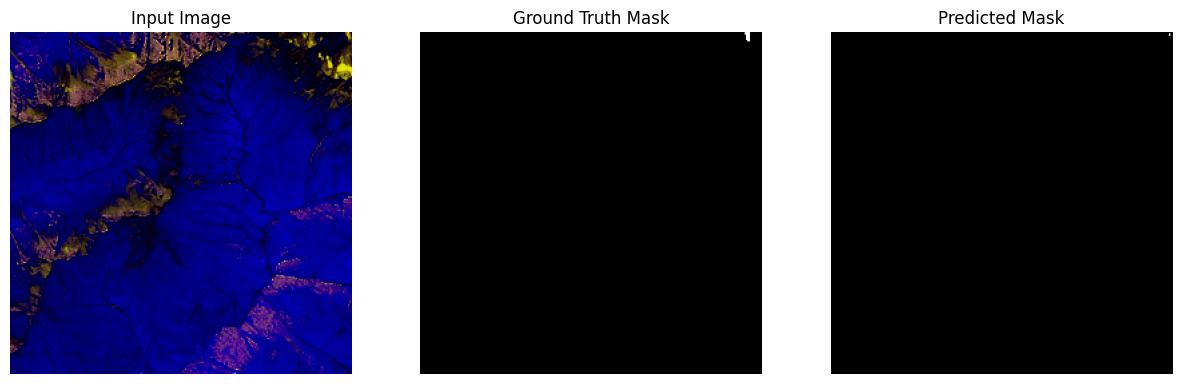

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.6226415..1.0].



Displaying Sample 8/18


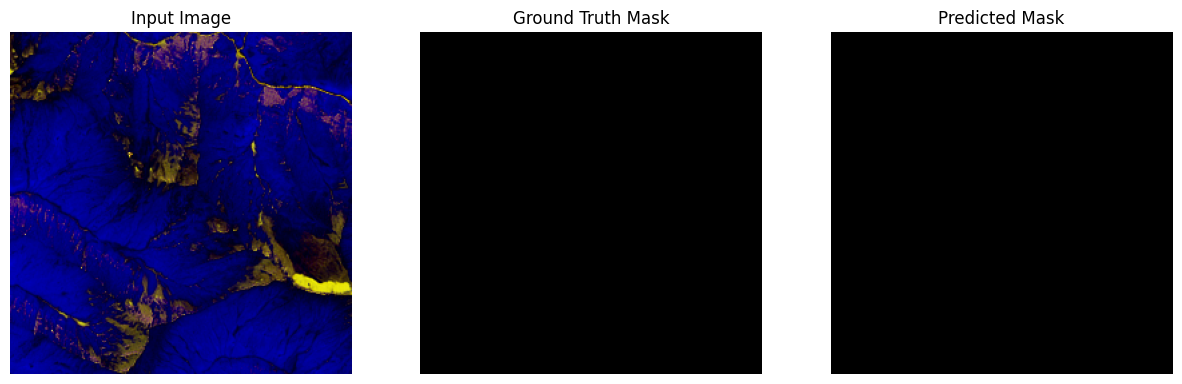

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.3813814..1.0].



Displaying Sample 9/18


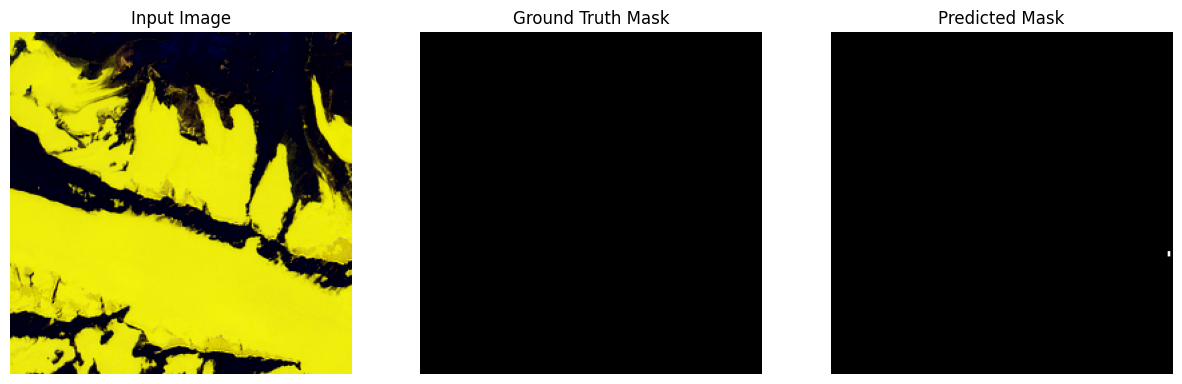

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5905512..1.0].



Displaying Sample 10/18


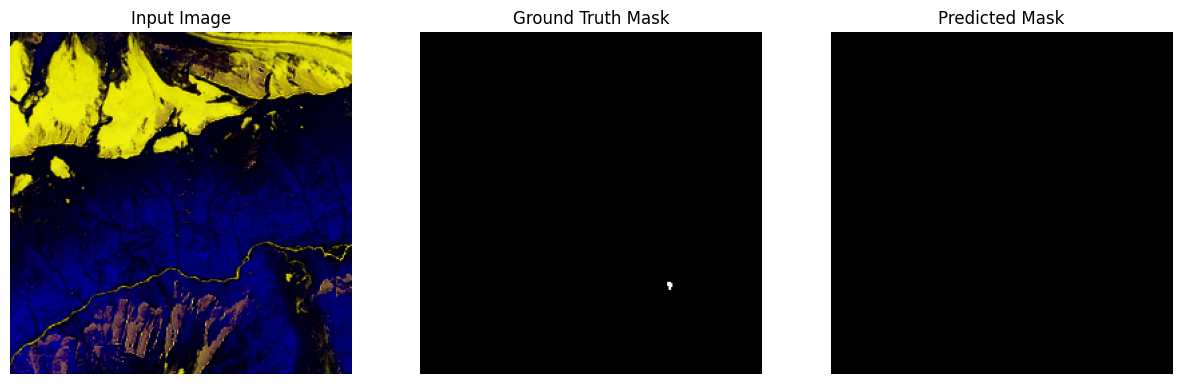

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.572093..1.0].



Displaying Sample 11/18


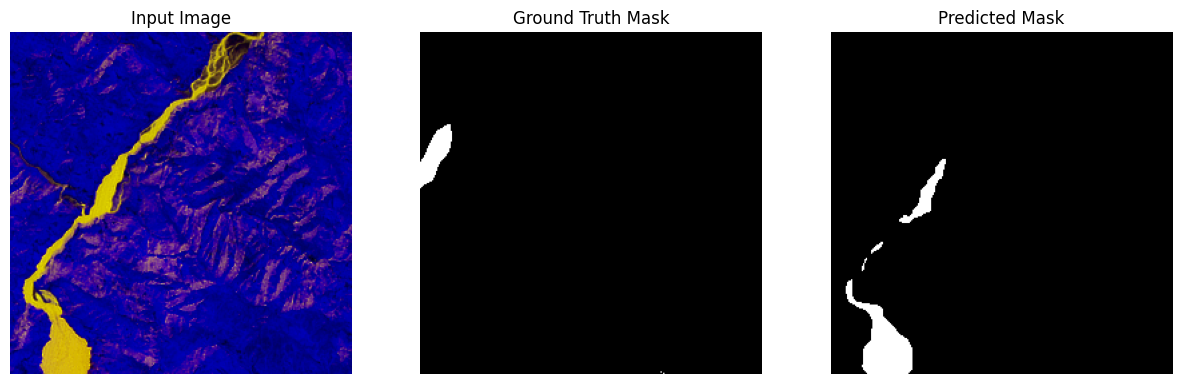

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.3941019..1.0].



Displaying Sample 12/18


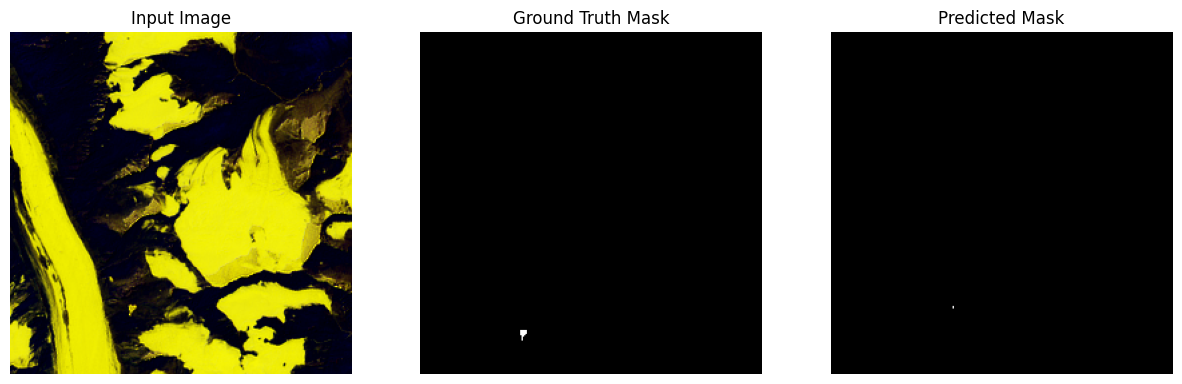

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5897436..1.0].



Displaying Sample 13/18


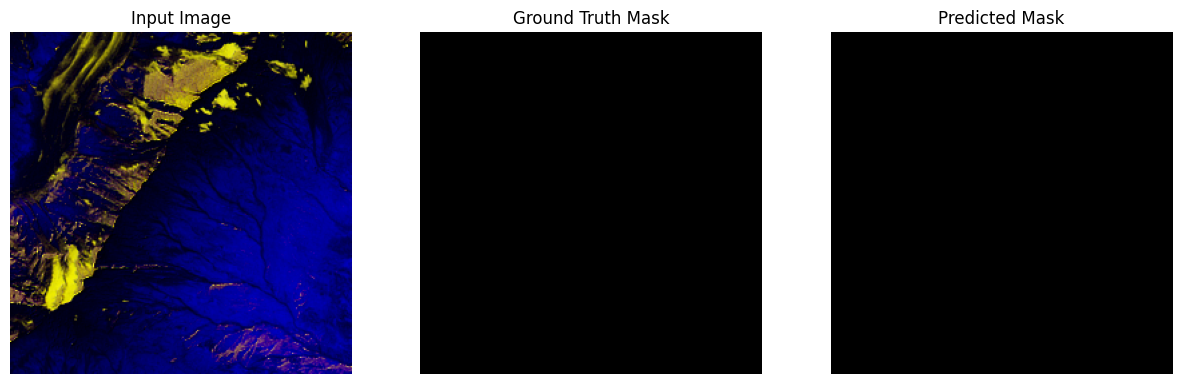

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.3702422..1.0].



Displaying Sample 14/18


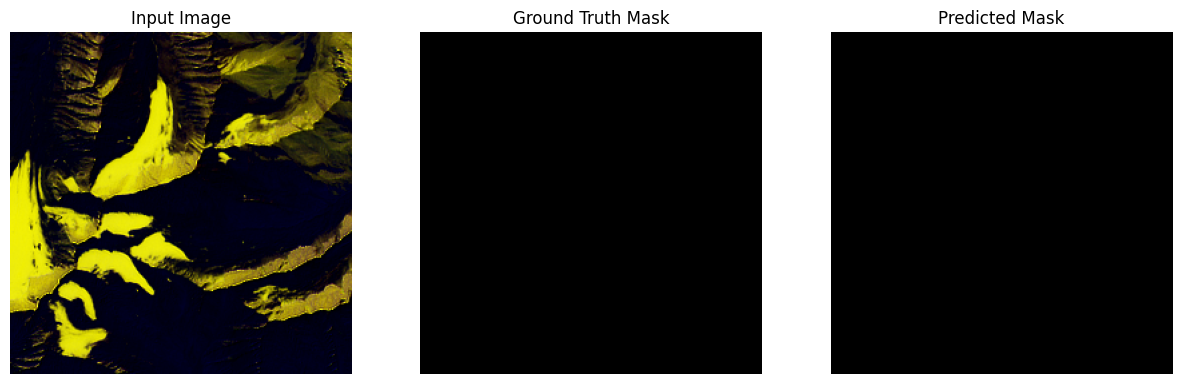

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.640678..1.0].



Displaying Sample 15/18


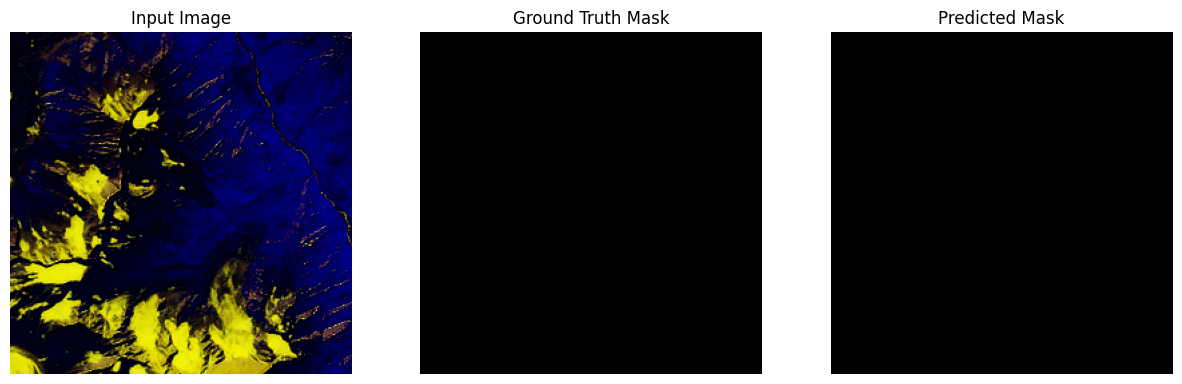

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.3263158..1.0].



Displaying Sample 16/18


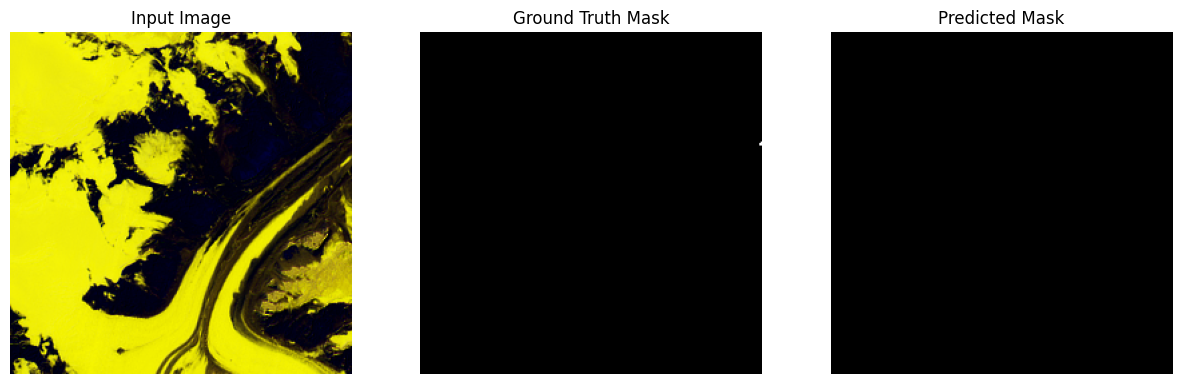

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.53797466..0.86013985].



Displaying Sample 17/18


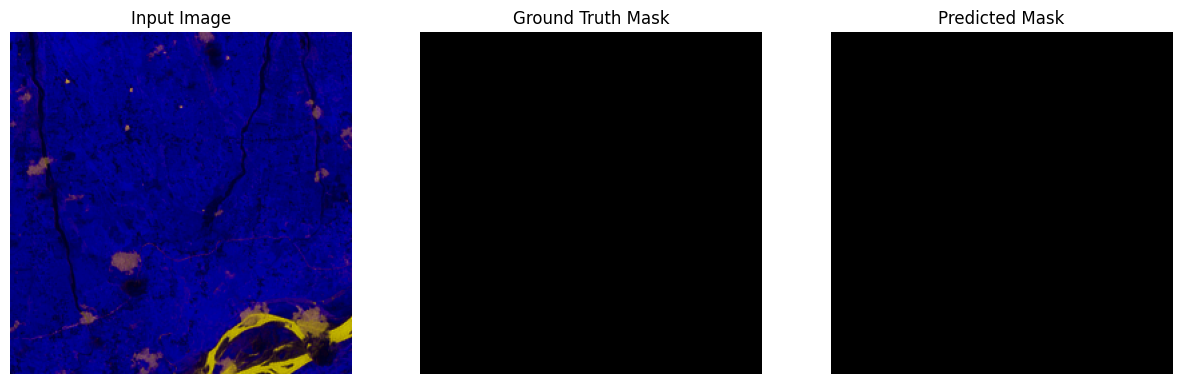


Displaying Sample 18/18


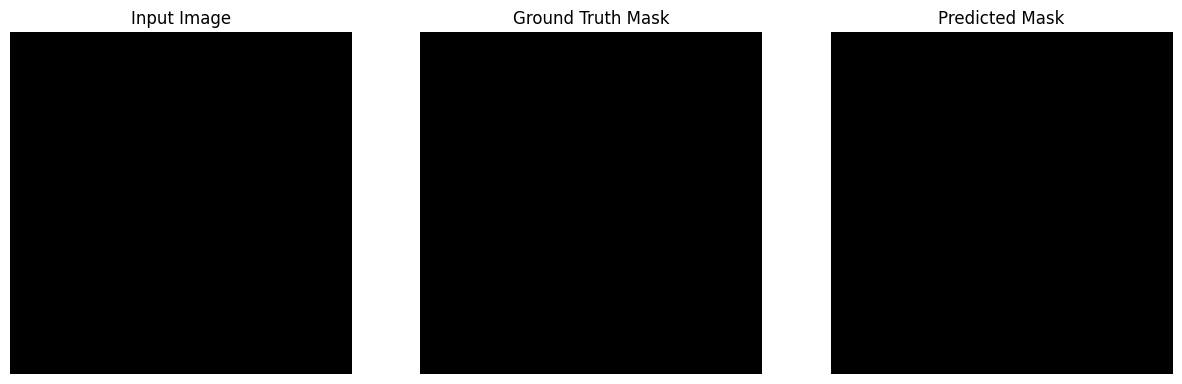

In [52]:
import matplotlib.pyplot as plt
import numpy as np
import torch # Make sure torch is imported

def visualize_all_predictions(dataset, model, device="cuda"):
    """
    Plots side-by-side comparisons for EVERY sample in the dataset.
    """
    print(f"Generating visualizations for all {len(dataset)} test samples...")
    model.eval()
    
    # Loop through the entire dataset
    for idx in range(len(dataset)):
        sample = dataset[idx]
        image, mask = sample["image"], sample["mask"]

        with torch.no_grad():
            # Get model prediction
            pred_mask = torch.sigmoid(model(image.unsqueeze(0).to(device)))
            pred_mask = (pred_mask > 0.5).float().cpu().squeeze(0)

        # Prepare image for plotting
        display_image = image.numpy().transpose(1, 2, 0)[:, :, :3]
        
        # --- Plotting ---
        print(f"\nDisplaying Sample {idx + 1}/{len(dataset)}")
        fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
        
        ax1.imshow(display_image)
        ax1.set_title("Input Image")
        ax1.axis("off")
        
        ax2.imshow(mask.squeeze(), cmap="gray")
        ax2.set_title("Ground Truth Mask")
        ax2.axis("off")

        ax3.imshow(pred_mask.squeeze(), cmap="gray")
        ax3.set_title("Predicted Mask")
        ax3.axis("off")
        
        plt.show()

# This is the code you would run in your notebook cell
if __name__ == '__main__':
    # Ensure your 'test_dataset', 'model', and 'DEVICE' variables are defined
    # from the previous evaluation step.
    
    visualize_all_predictions(test_dataset, model, device=DEVICE)

### Testing about why the model was perofrming bad

In [53]:
# --- Sanity Check 1: Check initial model output ---
print("--- Running Sanity Check 1: Initial Output ---")
# Get a single sample from the test set
sample_data = test_dataset[0] 
image = sample_data["image"].unsqueeze(0).to(DEVICE) # Add batch dim and send to device

# Create a fresh, untrained model
fresh_model = AttentionUNET(in_channels=8, out_channels=1).to(DEVICE)
fresh_model.eval()

with torch.no_grad():
    prediction = fresh_model(image)
    prediction_prob = torch.sigmoid(prediction)

print(f"Output range of a fresh model (logits): min={prediction.min():.2f}, max={prediction.max():.2f}")
print(f"Output range after sigmoid (probabilities): min={prediction_prob.min():.2f}, max={prediction_prob.max():.2f}")

--- Running Sanity Check 1: Initial Output ---
Output range of a fresh model (logits): min=-1.50, max=0.60
Output range after sigmoid (probabilities): min=0.18, max=0.65


In [54]:
# --- Sanity Check 2: Check initial loss value ---
print("\n--- Running Sanity Check 2: Initial Loss ---")
try:
    # Get one batch from the training loader
    batch = next(iter(train_loader))
    images = batch["image"].to(DEVICE)
    masks = batch["mask"].to(DEVICE)

    # Use the same fresh model from Step 1
    loss_fn = DiceBCELoss()
    prediction = fresh_model(images)
    loss = loss_fn(prediction, masks)

    print(f"Initial loss on one batch: {loss.item():.4f}")
except Exception as e:
    print(f"An error occurred: {e}")


--- Running Sanity Check 2: Initial Loss ---
Initial loss on one batch: 1.6993


In [55]:
# --- Sanity Check 3: The Overfitting Test ---
print("\n--- Running Sanity Check 3: The Overfitting Test ---")

# Get one single batch of data from your train_loader
single_batch = next(iter(train_loader))
images = single_batch["image"].to(DEVICE)
masks = single_batch["mask"].to(DEVICE)

# Create a new model and optimizer for this test
# Ensure you are using the correct model class (e.g., AttentionUNET)
overfit_model = AttentionUNET(in_channels=8, out_channels=1).to(DEVICE)
overfit_optimizer = optim.Adam(overfit_model.parameters(), lr=1e-3) # Using the higher learning rate
loss_fn = DiceBCELoss() # Using the better loss function

overfit_model.train()
for i in tqdm(range(200), desc="Overfitting..."):
    # Forward pass
    predictions = overfit_model(images)
    loss = loss_fn(predictions, masks)

    # Backward pass
    overfit_optimizer.zero_grad()
    loss.backward()
    overfit_optimizer.step()
    
    if (i + 1) % 20 == 0:
        print(f"  Iteration {i+1}, Loss: {loss.item():.6f}")

print("Overfitting test complete.")


--- Running Sanity Check 3: The Overfitting Test ---


Overfitting...:  10%|██████▌                                                          | 20/200 [01:20<18:47,  6.27s/it]

  Iteration 20, Loss: 1.305526


Overfitting...:  20%|█████████████                                                    | 40/200 [02:45<17:36,  6.61s/it]

  Iteration 40, Loss: 1.207260


...

  Iteration 160, Loss: 0.918327


Overfitting...:  90%|█████████████████████████████████████████████████████████▌      | 180/200 [12:48<02:14,  6.71s/it]

  Iteration 180, Loss: 0.865463


Overfitting...: 100%|████████████████████████████████████████████████████████████████| 200/200 [14:15<00:00,  4.28s/it]

  Iteration 200, Loss: 0.690620
Overfitting test complete.


### Correct code with newer aand higher learning rate

In [46]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm import tqdm
import albumentations as A
import rasterio
import numpy as np
import glob

# ==============================================================================
# 1. DATASET CLASS
# ==============================================================================
class GlacialLakeDataset(Dataset):
    def __init__(self, image_dir, mask_dir, augmentations=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.augmentations = augmentations
        self.image_files = sorted(glob.glob(os.path.join(image_dir, "*.tif")))

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = self.image_files[idx]
        img_filename = os.path.basename(img_path)
        mask_filename = img_filename.replace('input_stack_chunk_', 'lake_mask_chunk_')
        mask_path = os.path.join(self.mask_dir, mask_filename)

        with rasterio.open(img_path) as src:
            dtype = src.profile['dtype']
            if np.issubdtype(dtype, np.integer):
                max_val = np.iinfo(dtype).max
            else:
                max_val = 1.0
            image = src.read().astype(np.float32) / max_val

        with rasterio.open(mask_path) as src:
            mask = src.read(1)
            mask = (mask > 0).astype(np.float32)

        if self.augmentations:
            augmented = self.augmentations(image=image.transpose(1, 2, 0), mask=mask)
            image = augmented['image'].transpose(2, 0, 1)
            mask = augmented['mask']

        if mask.ndim == 2:
            mask = np.expand_dims(mask, axis=0)
            
        return {
            "image": torch.from_numpy(image).float(),
            "mask": torch.from_numpy(mask).float()
        }

# ==============================================================================
# 2. ATTENTION U-NET MODEL ARCHITECTURE
# ==============================================================================
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.double_conv(x)

class AttentionBlock(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super(AttentionBlock, self).__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )
        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )
        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        psi = self.relu(g1 + x1)
        psi = self.psi(psi)
        return x * psi

class AttentionUNET(nn.Module):
    def __init__(self, in_channels=8, out_channels=1, features=[64, 128, 256, 512]):
        super(AttentionUNET, self).__init__()
        self.downs = nn.ModuleList()
        self.ups = nn.ModuleList()
        self.attentions = nn.ModuleList()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        for feature in features:
            self.downs.append(DoubleConv(in_channels, feature))
            in_channels = feature

        self.bottleneck = DoubleConv(features[-1], features[-1] * 2)

        for feature in reversed(features):
            self.attentions.append(AttentionBlock(F_g=feature, F_l=feature, F_int=feature // 2))
            self.ups.append(nn.ConvTranspose2d(feature * 2, feature, kernel_size=2, stride=2))
            self.ups.append(DoubleConv(feature * 2, feature))

        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        skip_connections = []
        for down in self.downs:
            x = down(x)
            skip_connections.append(x)
            x = self.pool(x)
        x = self.bottleneck(x)
        skip_connections = skip_connections[::-1]
        for i in range(len(self.ups) // 2):
            x = self.ups[i*2](x)
            skip_connection = skip_connections[i]
            if x.shape != skip_connection.shape:
                x = nn.functional.interpolate(x, size=skip_connection.shape[2:])
            attention_map = self.attentions[i](g=x, x=skip_connection)
            concat_skip = torch.cat((attention_map, x), dim=1)
            x = self.ups[i*2 + 1](concat_skip)
        return self.final_conv(x)

# ==============================================================================
# 3. IMPROVED LOSS FUNCTION
# ==============================================================================
class DiceLoss(nn.Module):
    def __init__(self):
        super(DiceLoss, self).__init__()
    def forward(self, inputs, targets, smooth=1):
        inputs = torch.sigmoid(inputs)
        inputs = inputs.view(-1)
        targets = targets.view(-1)
        intersection = (inputs * targets).sum()
        dice = (2.*intersection + smooth)/(inputs.sum() + targets.sum() + smooth)
        return 1 - dice

class DiceBCELoss(nn.Module):
    def __init__(self):
        super(DiceBCELoss, self).__init__()
        self.dice_loss = DiceLoss()
        self.bce_loss = nn.BCEWithLogitsLoss()
    def forward(self, inputs, targets, smooth=1):
        total_loss = self.bce_loss(inputs, targets) + self.dice_loss(inputs, targets)
        return total_loss

# ==============================================================================
# 4. TRAINING AND VALIDATION FUNCTIONS
# ==============================================================================
def train_one_epoch(loader, model, optimizer, loss_fn, device):
    loop = tqdm(loader, desc="Training")
    running_loss = 0.0
    model.train()
    for batch in loop:
        images, masks = batch["image"].to(device), batch["mask"].to(device)
        predictions = model(images)
        loss = loss_fn(predictions, masks)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        loop.set_postfix(loss=loss.item())
    return running_loss / len(loader)

def evaluate_model(loader, model, loss_fn, device):
    model.eval()
    running_loss = 0.0
    with torch.no_grad():
        for batch in tqdm(loader, desc="Validation"):
            images, masks = batch["image"].to(device), batch["mask"].to(device)
            predictions = model(images)
            loss = loss_fn(predictions, masks)
            running_loss += loss.item()
    return running_loss / len(loader)

# ==============================================================================
# 5. MAIN EXECUTION BLOCK
# ==============================================================================
if __name__ == '__main__':
    # --- Configuration ---
    LEARNING_RATE = 1e-3  # Using the more effective learning rate
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    BATCH_SIZE = 4
    NUM_WORKERS = 0
    NUM_EPOCHS = 50 # Increased epochs for better training of the complex model

    TRAIN_IMG_DIR = r"D:\Coding\Hackathon\Glacial_Lake_Detection_BAH-2025\data\LISS3\segments\input_stack\LISS3_1\training"
    TRAIN_MSK_DIR = r"D:\Coding\Hackathon\Glacial_Lake_Detection_BAH-2025\data\LISS3\segments\layer_mask\LISS3_1\training"
    VAL_IMG_DIR = r"D:\Coding\Hackathon\Glacial_Lake_Detection_BAH-2025\data\LISS3\segments\input_stack\LISS3_1\validation"
    VAL_MSK_DIR = r"D:\Coding\Hackathon\Glacial_Lake_Detection_BAH-2025\data\LISS3\segments\layer_mask\LISS3_1\validation"

    # --- Data Augmentation ---
    train_transforms = A.Compose([
        A.HorizontalFlip(p=0.5), A.VerticalFlip(p=0.5), A.RandomRotate90(p=0.5),
    ])

    # --- Datasets and DataLoaders ---
    train_dataset = GlacialLakeDataset(TRAIN_IMG_DIR, TRAIN_MSK_DIR, train_transforms)
    val_dataset = GlacialLakeDataset(VAL_IMG_DIR, VAL_MSK_DIR, None)
    train_loader = DataLoader(train_dataset, BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
    val_loader = DataLoader(val_dataset, BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

    # --- Model, Loss, and Optimizer ---
    model = AttentionUNET(in_channels=8, out_channels=1).to(DEVICE)
    loss_fn = DiceBCELoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    # --- Training Loop ---
    print(f"Starting full training run on {DEVICE}...")
    best_val_loss = float("inf")
    for epoch in range(NUM_EPOCHS):
        print(f"\n--- Epoch {epoch+1}/{NUM_EPOCHS} ---")
        train_loss = train_one_epoch(train_loader, model, optimizer, loss_fn, DEVICE)
        val_loss = evaluate_model(val_loader, model, loss_fn, DEVICE)
        print(f"Epoch {epoch+1} Summary: Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), "best_model_attention.pth") # Saved with a new name
            print("=> Saved new best model")

    print("\nTraining complete!")

Starting full training run on cuda...

--- Epoch 1/50 ---


Validation: 100%|████████████████████████████████████████████████████████████████████████| 5/5 [00:03<00:00,  1.36it/s]


Epoch 1 Summary: Train Loss: 1.3409 | Val Loss: 1.2401
=> Saved new best model

--- Epoch 2/50 ---


Validation: 100%|████████████████████████████████████████████████████████████████████████| 5/5 [00:03<00:00,  1.34it/s]


Epoch 2 Summary: Train Loss: 1.1576 | Val Loss: 1.0955
=> Saved new best model

--- Epoch 3/50 ---


...

Epoch 48 Summary: Train Loss: 0.8919 | Val Loss: 0.9189

--- Epoch 49/50 ---


Validation: 100%|████████████████████████████████████████████████████████████████████████| 5/5 [00:03<00:00,  1.25it/s]


Epoch 49 Summary: Train Loss: 0.8729 | Val Loss: 0.9208

--- Epoch 50/50 ---


Validation: 100%|████████████████████████████████████████████████████████████████████████| 5/5 [00:03<00:00,  1.26it/s]


Epoch 50 Summary: Train Loss: 0.8571 | Val Loss: 0.8613
=> Saved new best model

Training complete!
